# Stinger Delay - Clough Bus EDA Notebook
Exploratory Data Analysis on Clough bus data

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('clough_bus_data.csv')

# Parse snapshot_time
df['snapshot_time'] = pd.to_datetime(
    df['snapshot_time'].astype(str).str.replace(r'\s*[A-Z]{2,4}$', '', regex=True)
)

# Parse ETA from weird /Date(ms)/ format in CSV
df['eta_ms'] = df['estimated_time_arrival'].str.extract(r'(\d+)').astype(float)
df['eta_time'] = pd.to_datetime(df['eta_ms'], unit='ms')
df['eta_time'] = (
    df['eta_time']
    .dt.tz_localize('UTC')
    .dt.tz_convert('America/New_York')
    .dt.tz_localize(None)
)

# Remaining time in seconds
df['remaining_time_sec'] = (df['eta_time'] - df['snapshot_time']).dt.total_seconds()

# Time features
df['hour'] = df['snapshot_time'].dt.hour
df['day_of_week'] = df['snapshot_time'].dt.day_name()
df['date'] = df['snapshot_time'].dt.date

# Stationary flag
df['is_stationary'] = df['vehicle_speed'] < 1

print('Data Shape:', df.shape)
print('Bus IDs:', sorted(df['vehicle_id'].unique()))
print('Date Range:', df['snapshot_time'].min(), 'to', df['snapshot_time'].max())
df.head()

Data Shape: (12076, 15)
Bus IDs: [5, 8, 11, 13, 14, 15, 16, 31, 34, 35, 37, 38, 41]
Date Range: 2026-03-02 11:27:43 to 2026-03-06 08:32:46


,snapshot_time,vehicle_id,route_id,route_stop_id,vehicle_lat,vehicle_lon,vehicle_speed,estimated_time_arrival,eta_ms,eta_time,remaining_time_sec,hour,day_of_week,date,is_stationary
0,2026-03-02 11:27:43,8,28,NaN,33.779320,-84.388770,13.001074,/Date(1772469009862)/,1.772469e+12,2026-03-02 11:30:09.862,146.862,11,Monday,2026-03-02,False
1,2026-03-02 11:27:43,38,28,NaN,33.775274,-84.396138,0.000000,/Date(1772468866862)/,1.772469e+12,2026-03-02 11:27:46.862,3.862,11,Monday,2026-03-02,True
2,2026-03-02 11:27:43,15,28,NaN,33.780822,-84.386406,0.000000,/Date(1772468863862)/,1.772469e+12,2026-03-02 11:27:43.862,0.862,11,Monday,2026-03-02,True
3,2026-03-02 11:28:14,8,28,NaN,33.778200,-84.388780,0.999911,/Date(1772469002079)/,1.772469e+12,2026-03-02 11:30:02.079,108.079,11,Monday,2026-03-02,True
4,2026-03-02 11:28:14,38,28,NaN,33.775274,-84.396138,0.000000,/Date(1772468898079)/,1.772469e+12,2026-03-02 11:28:18.079,4.079,11,Monday,2026-03-02,True


## Window Selection
To make the data more clear, I randomly picked **3 random buses** that fit the criteria. For each:
- **Plots 1 & 2**: Used a 15-minute movement window (avg speed > 5 mph) within 12:30–2:30pm
- **Plot 2**: Used a slightly bigger window to provide added context (5 min before + stationary period + 5 min after)
- **Plot 3**: Used the full dataset of the selected buses

In [51]:
# Filter noon window 12:30–14:30
noon_df = df[
    ((df['snapshot_time'].dt.hour * 60 + df['snapshot_time'].dt.minute) >= (12 * 60 + 30)) &
    ((df['snapshot_time'].dt.hour * 60 + df['snapshot_time'].dt.minute) <= (14 * 60 + 30))
].copy()

noon_df['window'] = noon_df['snapshot_time'].dt.floor('15min')

window_stats = (
    noon_df.groupby(['vehicle_id', 'window'])
    .agg(avg_speed=('vehicle_speed', 'mean'), count=('vehicle_speed', 'count'))
    .reset_index()
)

good_windows = window_stats[window_stats['avg_speed'] > 5]
eligible_buses = good_windows['vehicle_id'].unique()

# Pick 3 random buses
selected_buses = random.sample(list(eligible_buses), min(3, len(eligible_buses)))
print('Selected buses:', selected_buses)

# For each bus, pick one random good window
bus_windows = {}
for bus in selected_buses:
    bus_good = good_windows[good_windows['vehicle_id'] == bus]
    chosen = bus_good.sample(1).iloc[0]
    bus_windows[bus] = chosen['window']
    print(f'  Bus {bus}: window starting {chosen["window"]}, avg_speed={chosen["avg_speed"]:.2f} mph')


def get_window_df(bus_id, start_time):
    end_time = start_time + pd.Timedelta(minutes=15)
    return df[
        (df['vehicle_id'] == bus_id) &
        (df['snapshot_time'] >= start_time) &
        (df['snapshot_time'] <= end_time)
    ].sort_values('snapshot_time').copy()


def get_stationary_context(bus_id):
    bus_df = df[df['vehicle_id'] == bus_id].sort_values('snapshot_time').copy()
    bus_df['bout'] = (
        (bus_df['is_stationary'] != bus_df['is_stationary'].shift()).cumsum()
    )
    stationary_bouts = (
        bus_df[bus_df['is_stationary']]
        .groupby('bout')['snapshot_time']
        .agg(['min', 'max', 'count'])
    )
    stationary_bouts['duration_min'] = (
        (stationary_bouts['max'] - stationary_bouts['min']).dt.total_seconds() / 60
    )
    valid = stationary_bouts[stationary_bouts['duration_min'] >= 2]
    if valid.empty:
        valid = stationary_bouts
    chosen_bout = valid.sample(1).iloc[0]
    context_start = chosen_bout['min'] - pd.Timedelta(minutes=5)
    context_end = chosen_bout['max'] + pd.Timedelta(minutes=5)
    return bus_df[
        (bus_df['snapshot_time'] >= context_start) &
        (bus_df['snapshot_time'] <= context_end)
    ].copy(), chosen_bout


stationary_contexts = {bus: get_stationary_context(bus) for bus in selected_buses}

Selected buses: [5, 38, 31]
  Bus 5: window starting 2026-03-04 14:15:00, avg_speed=6.45 mph
  Bus 38: window starting 2026-03-04 14:00:00, avg_speed=5.82 mph
  Bus 31: window starting 2026-03-03 12:30:00, avg_speed=5.41 mph


## Plot 1 — Snapshot Time × Remaining Time
**15-minute normal movement window** (avg speed > 5 mph) within 12:30–2:30pm, one panel per bus.

**Questions:** Are there jumps? Does remaining_time decrease consistently?

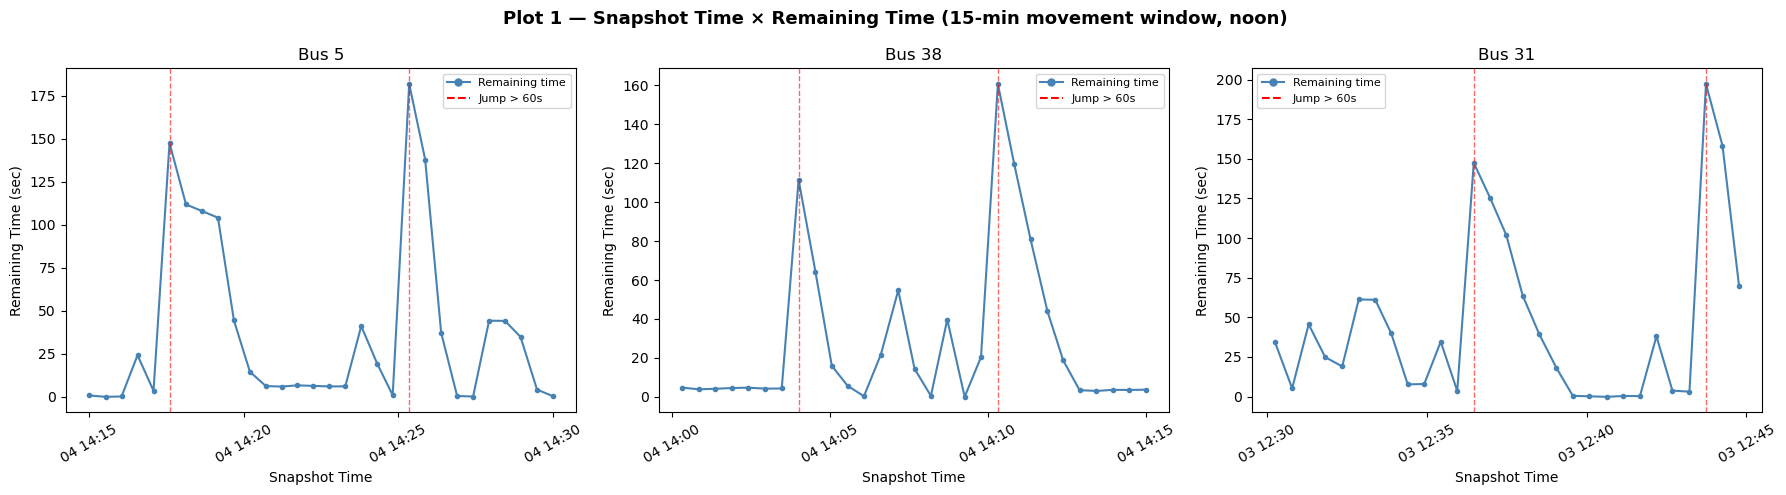


Things to look for:
- A smooth downward slope means ETA ticking down consistently, which is expected for a moving bus
- Red dashed lines mark jumps larger than 60 seconds; this means that the ETA resets when bus arrives and a new destination is assigned, or potential data glitches.
- Flat sections mean ETA has frozen, this makes sense if it coincides with low speed in Plot 2



In [52]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Plot 1 — Snapshot Time × Remaining Time (15-min movement window, noon)', fontsize=13, fontweight='bold')

for ax, bus in zip(axes, selected_buses):
    wdf = get_window_df(bus, bus_windows[bus])
    wdf['eta_change'] = wdf['remaining_time_sec'].diff()

    ax.plot(wdf['snapshot_time'], wdf['remaining_time_sec'],
            marker='o', markersize=3, linewidth=1.5, color='steelblue', label='Remaining time')

    # Mark large jumps over 60sec, likely means ETA reset
    jumps = wdf[wdf['eta_change'] > 60]
    for _, row in jumps.iterrows():
        ax.axvline(row['snapshot_time'], color='red', alpha=0.6, linestyle='--', linewidth=1)

    ax.set_title(f'Bus {bus}')
    ax.set_xlabel('Snapshot Time')
    ax.set_ylabel('Remaining Time (sec)')
    ax.tick_params(axis='x', rotation=30)

    legend_handles = [
        Line2D([0], [0], color='steelblue', marker='o', markersize=5, label='Remaining time'),
        Line2D([0], [0], color='red', linestyle='--', label='Jump > 60s')
    ]
    ax.legend(handles=legend_handles, fontsize=8)

plt.tight_layout()
plt.show()

print("""
Things to look for:
- A smooth downward slope means ETA ticking down consistently, which is expected for a moving bus
- Red dashed lines mark jumps larger than 60 seconds; this means that the ETA resets when bus arrives and a new destination is assigned, or potential data glitches.
- Flat sections mean ETA has frozen, this makes sense if it coincides with low speed in Plot 2
""")

## Plot 2 — Vehicle Speed × Remaining Time
**Stationary context window** (5 min before + stationary period + 5 min after), one panel per bus.

**Questions:** Does ETA continue decreasing when bus is stationary? Does ETA freeze when speed = 0?

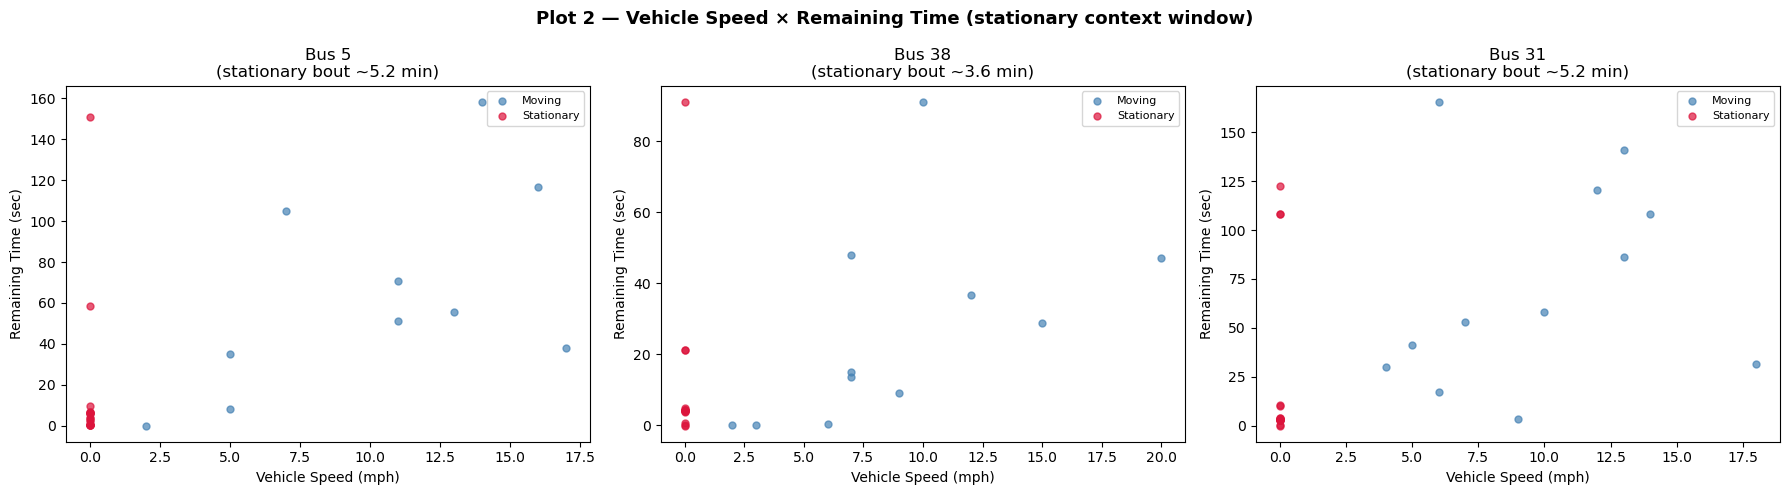


Things to look for:
- Red = relatively stationary (speed < 1), blue = bus is moving (speed > 1)
- If red points span a wide range of remaining_time values, this means ETA still changes while stopped. This potentially means that 
      the system updates ETA based on conditions even without movement
- If red points cluster at a single remaining_time, ETA is frozen during the stop. This makes sense since ETA shouldn't move 
      much when the bus is at a stop



In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Plot 2 — Vehicle Speed × Remaining Time (stationary context window)', fontsize=13, fontweight='bold')

for ax, bus in zip(axes, selected_buses):
    ctx_df, bout = stationary_contexts[bus]

    moving = ctx_df[~ctx_df['is_stationary']]
    stopped = ctx_df[ctx_df['is_stationary']]

    ax.scatter(moving['vehicle_speed'], moving['remaining_time_sec'],
               color='steelblue', alpha=0.7, s=25, label='Moving')
    ax.scatter(stopped['vehicle_speed'], stopped['remaining_time_sec'],
               color='crimson', alpha=0.7, s=25, label='Stationary')

    duration = bout['duration_min']
    ax.set_title(f'Bus {bus}\n(stationary bout ~{duration:.1f} min)')
    ax.set_xlabel('Vehicle Speed (mph)')
    ax.set_ylabel('Remaining Time (sec)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("""
Things to look for:
- Red = relatively stationary (speed < 1), blue = bus is moving (speed > 1)
- If red points span a wide range of remaining_time values, this means ETA still changes while stopped. This potentially means that 
      the system updates ETA based on conditions even without movement
- If red points cluster at a single remaining_time, ETA is frozen during the stop. This makes sense since ETA shouldn't move 
      much when the bus is at a stop
""")

## Plot 3 — Speed × ETA Change
Full dataset for selected buses.

**Question:** What is the relationship between current speed and how fast ETA changes?

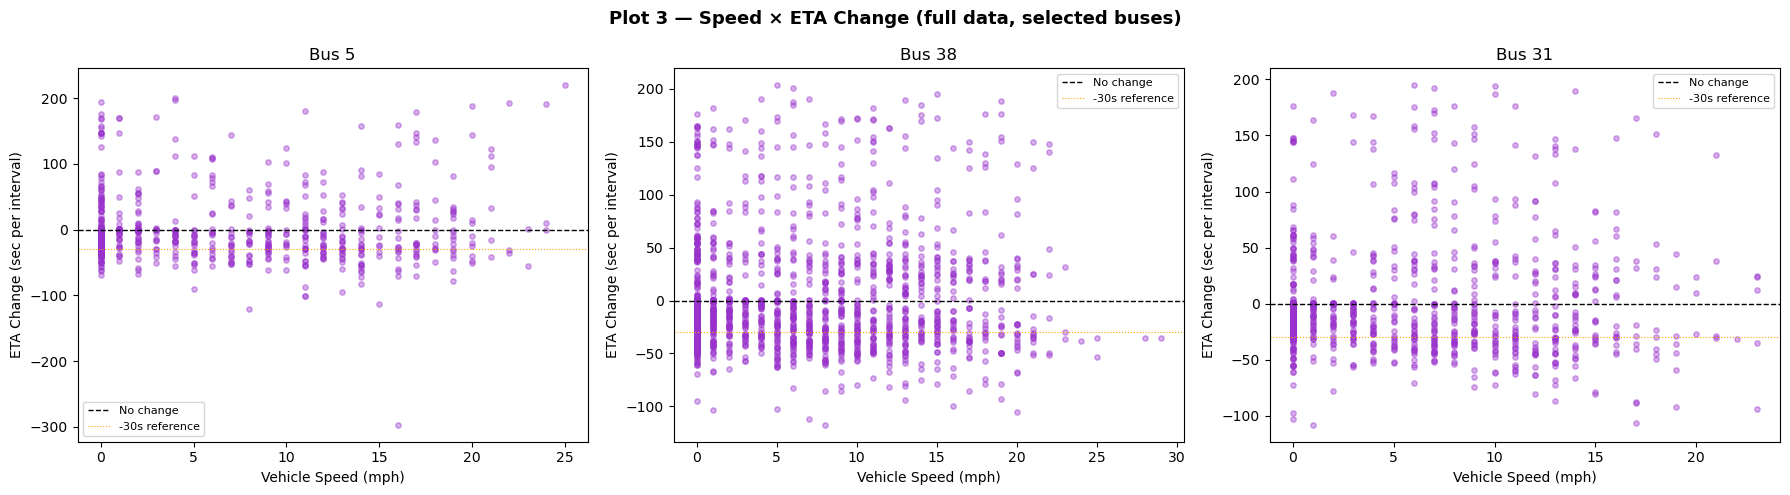


Interpretation:
- Points below 0 mean that ETA is counting down normally
- Points above 0 at low speed mean that ETA growing while barely moving, potentially due to congestion, re-routing, etc.
- Large negative outliers at higher speeds mean that there's a rapid ETA drop as bus approaches stop
- Resets greater than 300sec excluded to keep the plots readable



In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Plot 3 — Speed × ETA Change (full data, selected buses)', fontsize=13, fontweight='bold')

for ax, bus in zip(axes, selected_buses):
    bus_df = df[df['vehicle_id'] == bus].sort_values('snapshot_time').copy()
    bus_df['eta_change'] = bus_df['remaining_time_sec'].diff()
    # Exclude large resets (arrivals)
    plot_df = bus_df[bus_df['eta_change'].abs() < 300]

    ax.scatter(plot_df['vehicle_speed'], plot_df['eta_change'],
               alpha=0.4, s=15, color='darkorchid')
    ax.axhline(0, color='black', linewidth=1, linestyle='--', label='No change')
    ax.axhline(-30, color='orange', linewidth=0.8, linestyle=':', label='-30s reference')
    ax.set_title(f'Bus {bus}')
    ax.set_xlabel('Vehicle Speed (mph)')
    ax.set_ylabel('ETA Change (sec per interval)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("""
Interpretation:
- Points below 0 mean that ETA is counting down normally
- Points above 0 at low speed mean that ETA growing while barely moving, potentially due to congestion, re-routing, etc.
- Large negative outliers at higher speeds mean that there's a rapid ETA drop as bus approaches stop
- Resets greater than 300sec excluded to keep the plots readable
""")

## Plot 4 — Stationary Duration × Frequency (Histogram)
All buses, full dataset.

**Question:** How long do stationary bouts typically last?

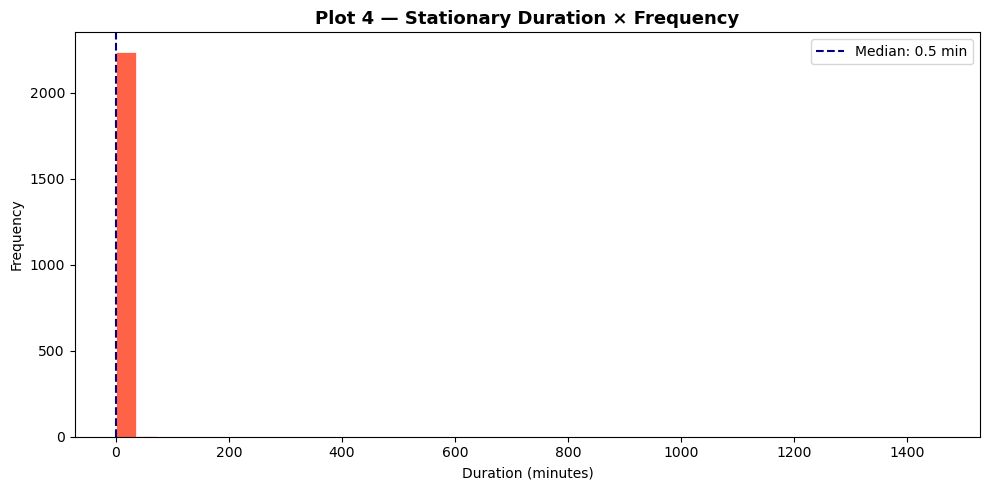


Summary (duration in minutes):
  Mean:        2.68
  Median:      0.52
  Max:         1455.65
  Total stationary bouts: 2247

Interpretation:
- Heavily right-skewed since most stops are brief (traffic lights, pedestrian crossings, etc.)
- Long tail since there are some outlier extended stops (scheduled layovers, driver breaks, etc.)



In [55]:
# Compute stationary bouts across all buses
df_sorted = df.sort_values(['vehicle_id', 'snapshot_time']).copy()
df_sorted['bout'] = (
    (df_sorted['is_stationary'] != df_sorted.groupby('vehicle_id')['is_stationary'].shift())
    .cumsum()
)

bout_info = (
    df_sorted[df_sorted['is_stationary']]
    .groupby(['vehicle_id', 'bout'])
    .agg(
        start=('snapshot_time', 'min'),
        end=('snapshot_time', 'max'),
        n_intervals=('snapshot_time', 'count')
    )
    .reset_index()
)
bout_info['duration_sec'] = (bout_info['end'] - bout_info['start']).dt.total_seconds()
bout_info['start_hour'] = bout_info['start'].dt.hour
bout_info['day_of_week'] = bout_info['start'].dt.day_name()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bout_info['duration_sec'] / 60, bins=40, color='tomato', edgecolor='white', linewidth=0.5)
median_min = bout_info['duration_sec'].median() / 60
ax.axvline(median_min, color='navy', linestyle='--', linewidth=1.5,
           label=f'Median: {median_min:.1f} min')
ax.set_title('Plot 4 — Stationary Duration × Frequency', fontsize=13, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"""
Summary (duration in minutes):
  Mean:        {bout_info['duration_sec'].mean()/60:.2f}
  Median:      {bout_info['duration_sec'].median()/60:.2f}
  Max:         {bout_info['duration_sec'].max()/60:.2f}
  Total stationary bouts: {len(bout_info)}

Interpretation:
- Heavily right-skewed since most stops are brief (traffic lights, pedestrian crossings, etc.)
- Long tail since there are some outlier extended stops (scheduled layovers, driver breaks, etc.)
""")

## Plot 5 — % Missing per Field
**Question:** Which fields have missing data and how much?

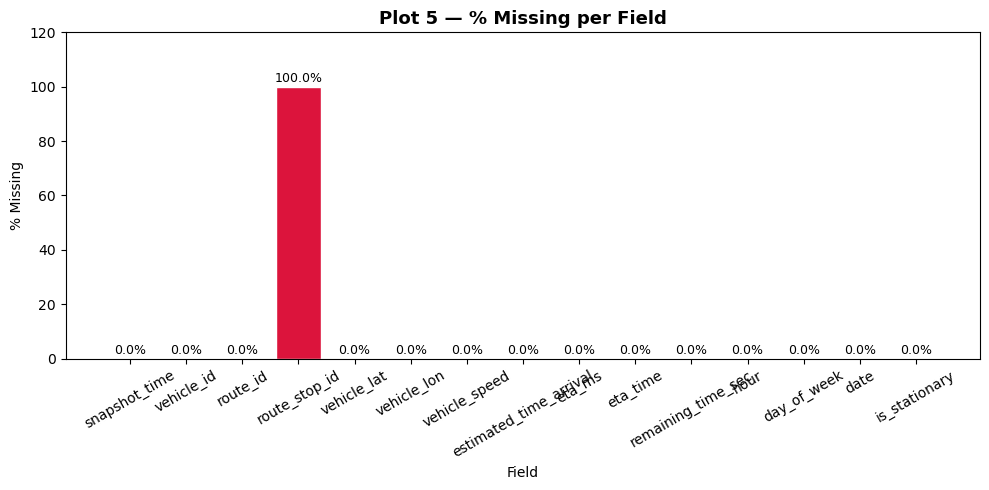

Missing values per field:
route_stop_id             100.0
snapshot_time               0.0
vehicle_id                  0.0
route_id                    0.0
vehicle_lat                 0.0
vehicle_lon                 0.0
vehicle_speed               0.0
estimated_time_arrival      0.0
eta_ms                      0.0
eta_time                    0.0
remaining_time_sec          0.0
hour                        0.0
day_of_week                 0.0
date                        0.0
is_stationary               0.0

Interpretation:
- route_stop_id is 100% missing since I never scraped that information in this dataset
- All other fields are complete, so ETA and speed analyses are unaffected by missing data



In [57]:
missing_pct = df.isnull().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['crimson' if v > 10 else 'steelblue' for v in missing_pct.values]
bars = ax.bar(missing_pct.index, missing_pct.values, color=colors, edgecolor='white')

for bar, val in zip(bars, missing_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Plot 5 — % Missing per Field', fontsize=13, fontweight='bold')
ax.set_xlabel('Field')
ax.set_ylabel('% Missing')
ax.set_ylim(0, max(missing_pct.max() * 1.2, 5))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Missing values per field:')
print(missing_pct.sort_values(ascending=False).to_string())
print("""
Interpretation:
- route_stop_id is 100% missing since I never scraped that information in this dataset
- All other fields are complete, so ETA and speed analyses are unaffected by missing data
""")

# Model Proposal — Stinger Delay

## Data Insights

The dataset contains ~12,000 GPS snapshots across 13 buses on route 28 (Clough), spanning 5 weekdays (Mon–Fri, March 2–6 2026). Key observations from EDA:

- ETA resets frequently, indicating arrivals rather than true delays; this means `eta_change` is a more reliable signal than `remaining_time_sec`
- Most stationary bouts are brief (traffic lights, pedestrian crossings, etc), but a long tail of extended stops (driver breaks, etc) exists
- Per-bus behavior varies because some vehicles show more frequent or longer stops than others

---

## Target Variable

**Recommended: 3-class delay classification**

| Class | Definition |
|---|---|
| On time | `eta_change` < 2 min |
| Slightly late | `eta_change` 2–5 min |
| Significantly late | `eta_change` > 5 min |

**Rationale:** A rider's decision is not "how many minutes late?" but "should I leave now or wait?" Three classes map directly to that decision and are more robust to the noise and ETA resets present in the data. Continuous regression would produce unstable targets given the signal noise, and a binary classifier loses severity information that is meaningful to the user.

---

## Proposed Model

**Recommended: Random Forest Classifier**

A Random Forest is an ensemble of decision trees, each trained on a random subset of features and data. Predictions are made by majority vote across all trees.

**Why it fits this dataset:**

- The dataset (~12k rows, 8 features) is in the sweet spot for tree ensemble methods since the dataset is large enough to generalize, yet small enough that gradient boosting offers diminishing returns
- Handles mixed feature types (continuous speed, binary flags, categorical hour/day) without scaling or encoding overhead
- Built-in feature importance rankings allow direct validation of EDA findings
- `class_weight='balanced'` handles any class imbalance between on-time and late observations without resampling.
- No stationarity assumption, meaning it's safe for GPS snapshot data that is not cleanly time-ordered across buses.

---

## Feature Set

### Inputs

| Feature | Source | Rationale |
|---|---|---|
| `vehicle_speed` | Raw | Directly signals congestion or stop |
| `remaining_time_sec` | Derived | Current ETA countdown — core delay signal |
| `eta_change` | Derived | Rate of ETA change — strongest delay indicator |
| `is_stationary` | Derived | Binary flag: speed < 1 mph |
| `stationary_duration` | Derived | Duration of current stop — longer stop = higher delay risk |
| `hour` | Derived | Time of day — captures rush hour patterns |
| `day_of_week` | Derived | Weekly scheduling patterns |
| `vehicle_id` | Raw | Per-bus fixed effects — some buses run systematically late |

### Output

| Feature | Source | Values |
|---|---|---|
| `delay_class` | Derived from `eta_change` | `on_time`, `slightly_late`, `significantly_late` |

**Features initially excluded from baseline:**

- `vehicle_lat` / `vehicle_lon` — Location could capture route segments that are consistently slow, but adds dimensionality that should be validated before inclusion. Would be great to add if we find a way to incorporate whether certain routes are slower than others.
- `route_stop_id` — Fully missing from CSV.
- `estimated_time_arrival` - It's a raw string, and it's cleaned up in `remaining_time_sec`.